In [ ]:
# Install PySpark in Colab
!pip install pyspark


In [ ]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Define the number of rows in the synthetic dataset
num_rows = 1000

# Generate synthetic data
data = {
    "Pregnancies": np.random.randint(0, 17, size=num_rows),
    "Glucose": np.random.normal(120, 30, num_rows).astype(int).clip(50, 200),
    "BloodPressure": np.random.normal(70, 12, num_rows).astype(int).clip(30, 122),
    "SkinThickness": np.random.normal(20, 10, num_rows).astype(int).clip(0, 99),
    "Insulin": np.random.normal(80, 40, num_rows).astype(int).clip(0, 900),
    "BMI": np.random.normal(32, 7, num_rows).clip(15, 50),
    "DiabetesPedigreeFunction": np.round(np.random.normal(0.5, 0.3, num_rows), 2),
    "Age": np.random.randint(21, 80, size=num_rows),
    "Outcome": np.random.randint(0, 2, size=num_rows)  # Random 0 or 1 for diabetic/non-diabetic
}

# Create DataFrame
synthetic_data = pd.DataFrame(data)
print(synthetic_data.head())

# Save synthetic data to CSV for reuse
synthetic_data.to_csv("synthetic_diabetes_data.csv", index=False)


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin        BMI  \
0            6       67             65             28       48  23.617635   
1           14      116             65             36        0  40.437287   
2           10       83             69             25       67  26.167447   
3            7      124             77             21       70  27.898869   
4            6      127             76             15       80  19.457894   

   DiabetesPedigreeFunction  Age  Outcome  
0                      0.22   22        0  
1                     -0.06   78        1  
2                      0.96   39        0  
3                      0.81   34        0  
4                      0.59   28        0  


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the synthetic data
data = pd.read_csv("synthetic_diabetes_data.csv")

# Separate features and target variable
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Ensure X_train and y_train are in NumPy array format
X_train = np.array(X_train)
y_train = np.array(y_train)

# Initialize Stratified K-Fold Cross-Validator
skf = StratifiedKFold(n_splits=5)
accuracies = []
f1_scores = []

# Train with Stratified K-Fold Cross Validation
for train_index, val_index in skf.split(X_train, y_train):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train[train_index], y_train[train_index])

    # Evaluate
    predictions = model.predict(X_train[val_index])
    accuracies.append(accuracy_score(y_train[val_index], predictions))
    f1_scores.append(f1_score(y_train[val_index], predictions))

print("Cross-Validated Accuracy:", np.mean(accuracies))
print("Cross-Validated F1 Score:", np.mean(f1_scores))


Cross-Validated Accuracy: 0.5225
Cross-Validated F1 Score: 0.516082113847172


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Input

# Reshape data to simulate time-series format
X_train_reshaped = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build CNN model
model = Sequential([
    Input(shape=(X_train_reshaped.shape[1], 1)),
    Conv1D(32, 2, activation='relu', padding='same'),
    MaxPooling1D(2, padding='same'),
    Conv1D(64, 2, activation='relu', padding='same'),
    MaxPooling1D(2, padding='same'),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train CNN
model.fit(X_train_reshaped, y_train, epochs=10, validation_data=(X_test_reshaped, y_test))
print("CNN Model Accuracy on Test Data:", model.evaluate(X_test_reshaped, y_test)[1])


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.4792 - loss: 0.6963 - val_accuracy: 0.5400 - val_loss: 0.6883
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4987 - loss: 0.6920 - val_accuracy: 0.5650 - val_loss: 0.6899
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5484 - loss: 0.6854 - val_accuracy: 0.5450 - val_loss: 0.6932
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5876 - loss: 0.6822 - val_accuracy: 0.5450 - val_loss: 0.6937
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5723 - loss: 0.6810 - val_accuracy: 0.5450 - val_loss: 0.6925
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6084 - loss: 0.6689 - val_accuracy: 0.5350 - val_loss: 0.6920
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5817 - loss: 0.6714 - val_accuracy: 0.5150 - val_loss: 0.6951
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6254 - loss: 0.6656 - val_accuracy: 0.5300 - val_loss

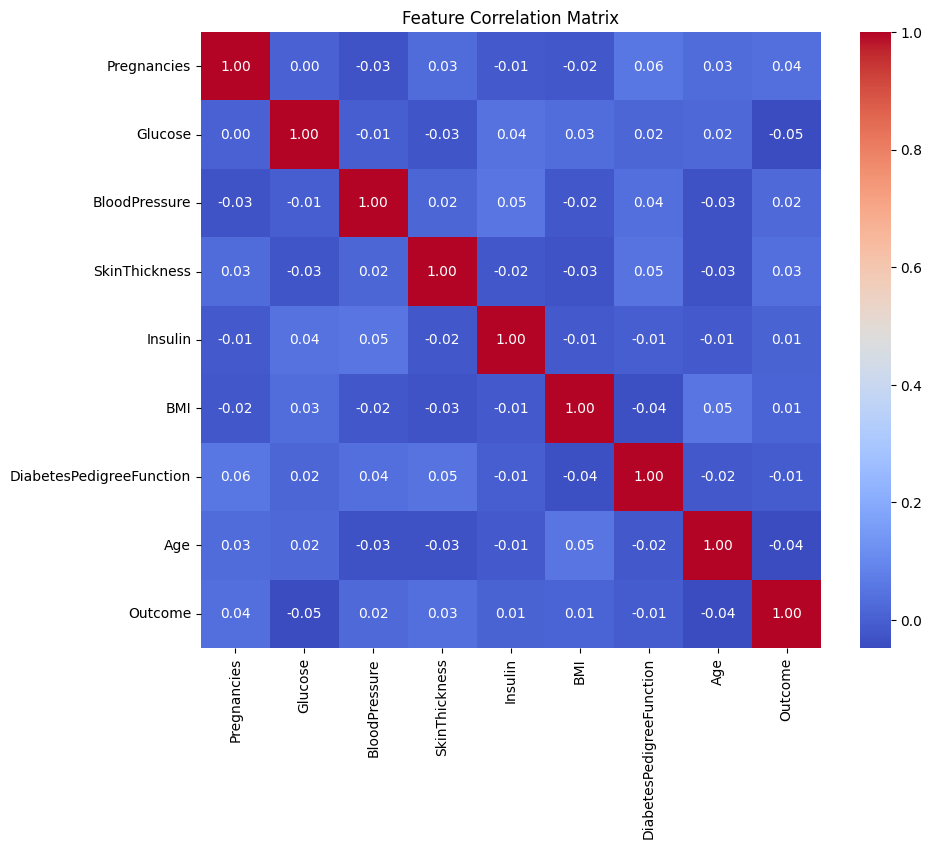

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix to visualize relationships between features
plt.figure(figsize=(10, 8))
sns.heatmap(synthetic_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()


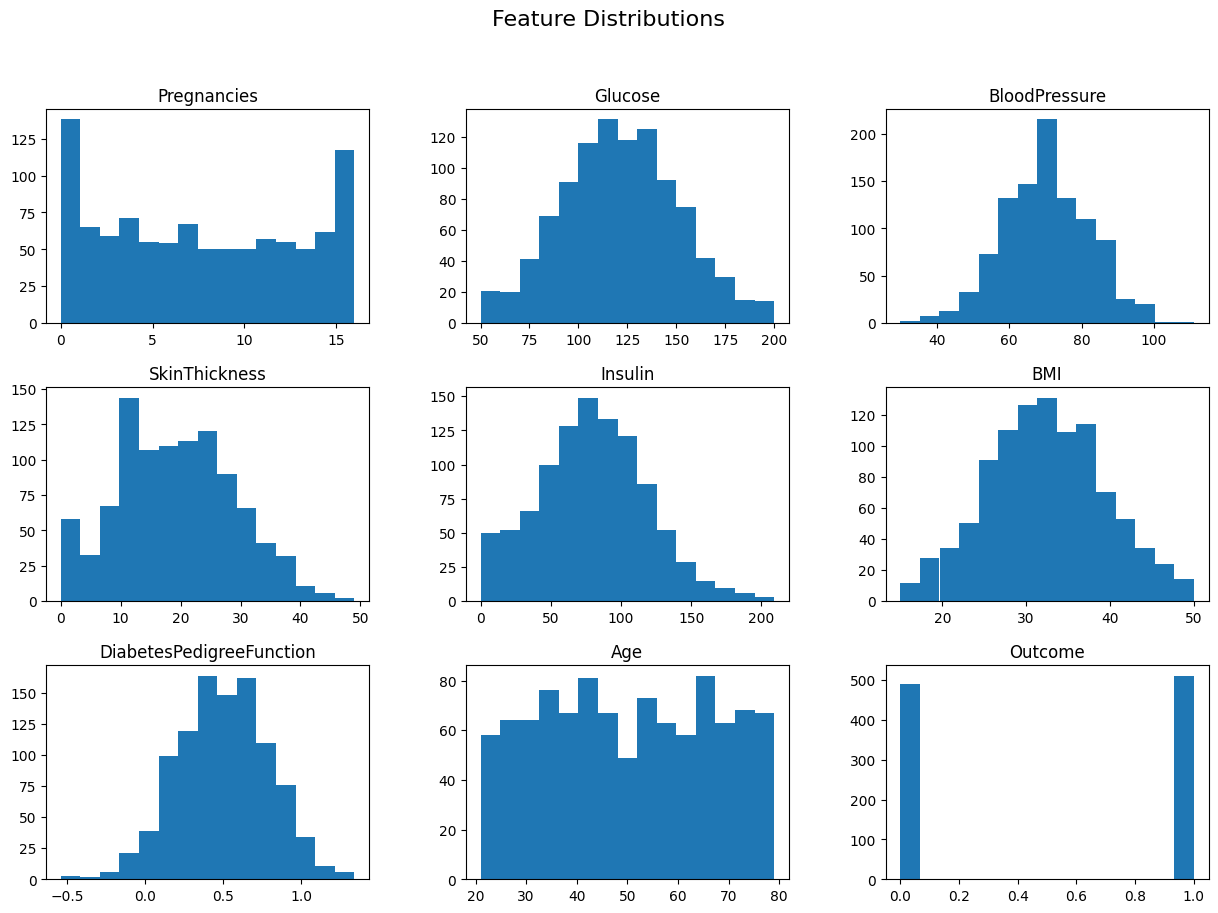

In [ ]:
# Plot distributions for continuous features
synthetic_data.hist(bins=15, figsize=(15, 10), grid=False)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


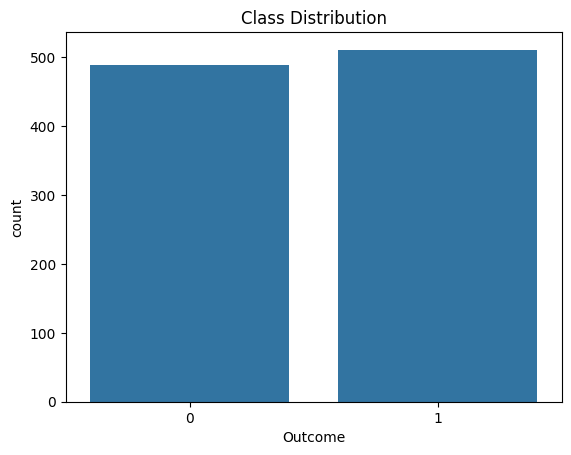

In [ ]:
# Check if classes are balanced
sns.countplot(data=synthetic_data, x="Outcome")
plt.title("Class Distribution")
plt.show()


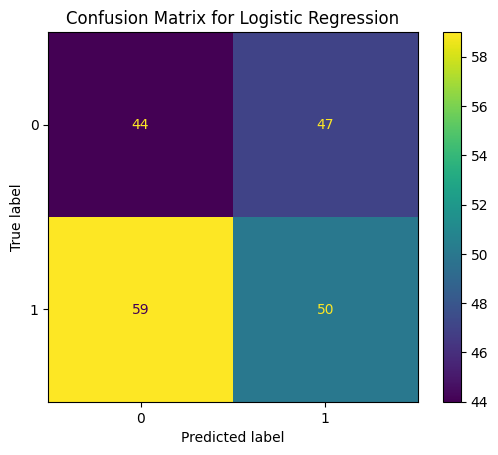

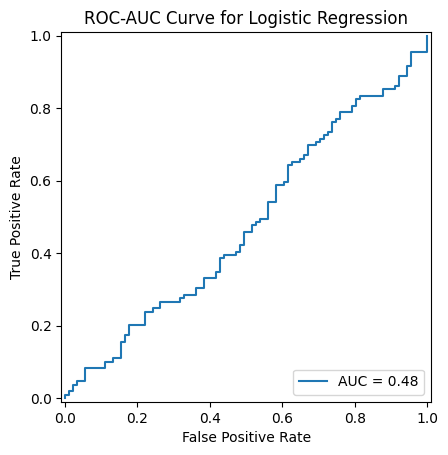

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression without GridSearch if it's not defined
if 'grid_search' not in globals():
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
else:
    model = grid_search.best_estimator_

# Logistic Regression Confusion Matrix
lr_predictions = model.predict(X_test)
lr_conf_matrix = confusion_matrix(y_test, lr_predictions)
ConfusionMatrixDisplay(lr_conf_matrix).plot()
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

# Logistic Regression ROC-AUC
lr_probs = model.predict_proba(X_test)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
roc_auc_lr = auc(lr_fpr, lr_tpr)
RocCurveDisplay(fpr=lr_fpr, tpr=lr_tpr, roc_auc=roc_auc_lr).plot()
plt.title("ROC-AUC Curve for Logistic Regression")
plt.show()


Cross-Validated Accuracy: 0.5225
Cross-Validated F1 Score: 0.516082113847172
Cross-Validated Precision: 0.5230360818268053
Cross-Validated Recall: 0.5121604938271604
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.4607 - loss: 0.6981 - val_accuracy: 0.4900 - val_loss: 0.6947
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5296 - loss: 0.6892 - val_accuracy: 0.5450 - val_loss: 0.6913
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5397 - loss: 0.6869 - val_accuracy: 0.5200 - val_loss: 0.6988
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5774 - loss: 0.6815 - val_accuracy: 0.5250 - val_loss: 0.6921
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5516 - loss: 0.6823 - val_accuracy: 0.5150 - val_loss: 0.7036
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5984 - loss: 0.6746 - val_accuracy: 0.5400 - val_loss: 0.6945
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5313 - loss:

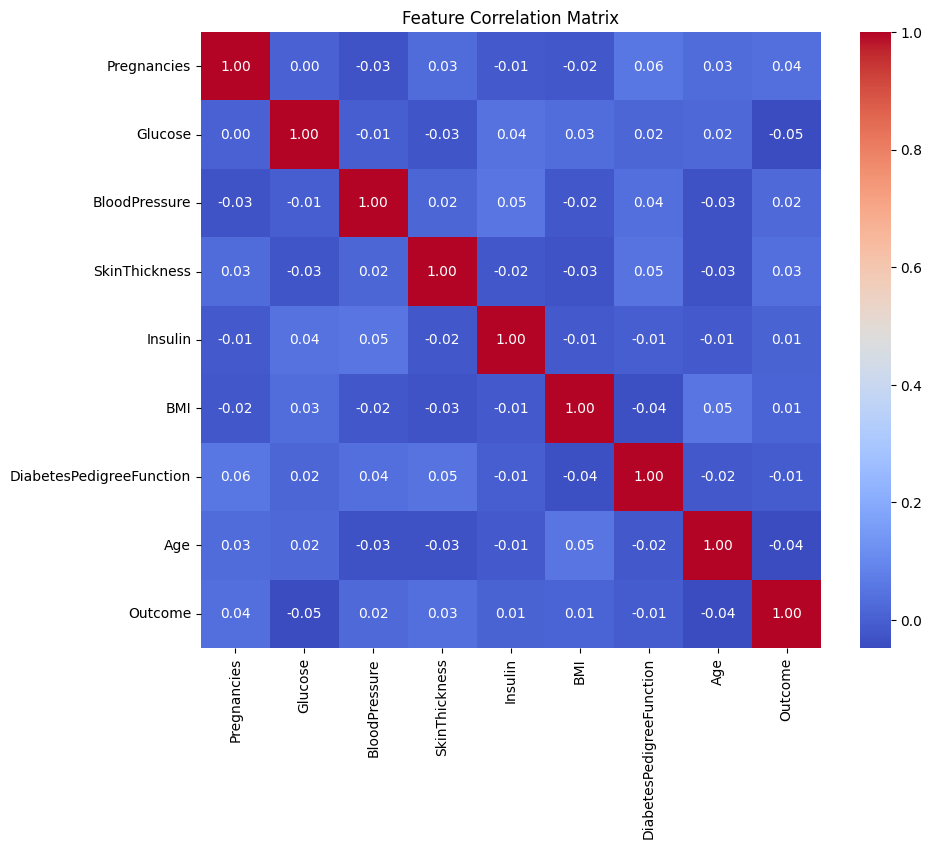

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Input
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
num_rows = 1000
data = {
    "Pregnancies": np.random.randint(0, 17, size=num_rows),
    "Glucose": np.random.normal(120, 30, num_rows).astype(int).clip(50, 200),
    "BloodPressure": np.random.normal(70, 12, num_rows).astype(int).clip(30, 122),
    "SkinThickness": np.random.normal(20, 10, num_rows).astype(int).clip(0, 99),
    "Insulin": np.random.normal(80, 40, num_rows).astype(int).clip(0, 900),
    "BMI": np.random.normal(32, 7, num_rows).clip(15, 50),
    "DiabetesPedigreeFunction": np.round(np.random.normal(0.5, 0.3, num_rows), 2),
    "Age": np.random.randint(21, 80, size=num_rows),
    "Outcome": np.random.randint(0, 2, size=num_rows)
}

# Create and save synthetic data
synthetic_data = pd.DataFrame(data)
synthetic_data.to_csv("synthetic_diabetes_data.csv", index=False)

# Load the dataset
data = pd.read_csv("synthetic_diabetes_data.csv")

# Handle missing values (Example: Fill missing values if any)
data.fillna(data.median(), inplace=True)

# Separate features and target
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)
# Ensure X_train and y_train are NumPy arrays
X_train_np = np.array(X_train)
y_train_np = np.array(y_train)

# Initialize Stratified K-Fold Cross-Validator
skf = StratifiedKFold(n_splits=5)
accuracies = []
f1_scores = []
precisions = []
recalls = []

# Train with Stratified K-Fold Cross Validation
for train_index, val_index in skf.split(X_train_np, y_train_np):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_np[train_index], y_train_np[train_index])

    # Evaluate
    preds = model.predict(X_train_np[val_index])
    accuracies.append(accuracy_score(y_train_np[val_index], preds))
    f1_scores.append(f1_score(y_train_np[val_index], preds))
    precisions.append(precision_score(y_train_np[val_index], preds))
    recalls.append(recall_score(y_train_np[val_index], preds))

print(f"Cross-Validated Accuracy: {np.mean(accuracies)}")
print(f"Cross-Validated F1 Score: {np.mean(f1_scores)}")
print(f"Cross-Validated Precision: {np.mean(precisions)}")
print(f"Cross-Validated Recall: {np.mean(recalls)}")

# CNN Implementation
X_train_reshaped = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

cnn_model = Sequential([
    Input(shape=(X_train_reshaped.shape[1], 1)),
    Conv1D(32, 2, activation='relu', padding='same'),
    MaxPooling1D(2, padding='same'),
    Conv1D(64, 2, activation='relu', padding='same'),
    MaxPooling1D(2, padding='same'),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train_reshaped, y_train, epochs=10, validation_data=(X_test_reshaped, y_test))

test_loss, test_accuracy = cnn_model.evaluate(X_test_reshaped, y_test)
print(f"CNN Test Accuracy: {test_accuracy}")

# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()


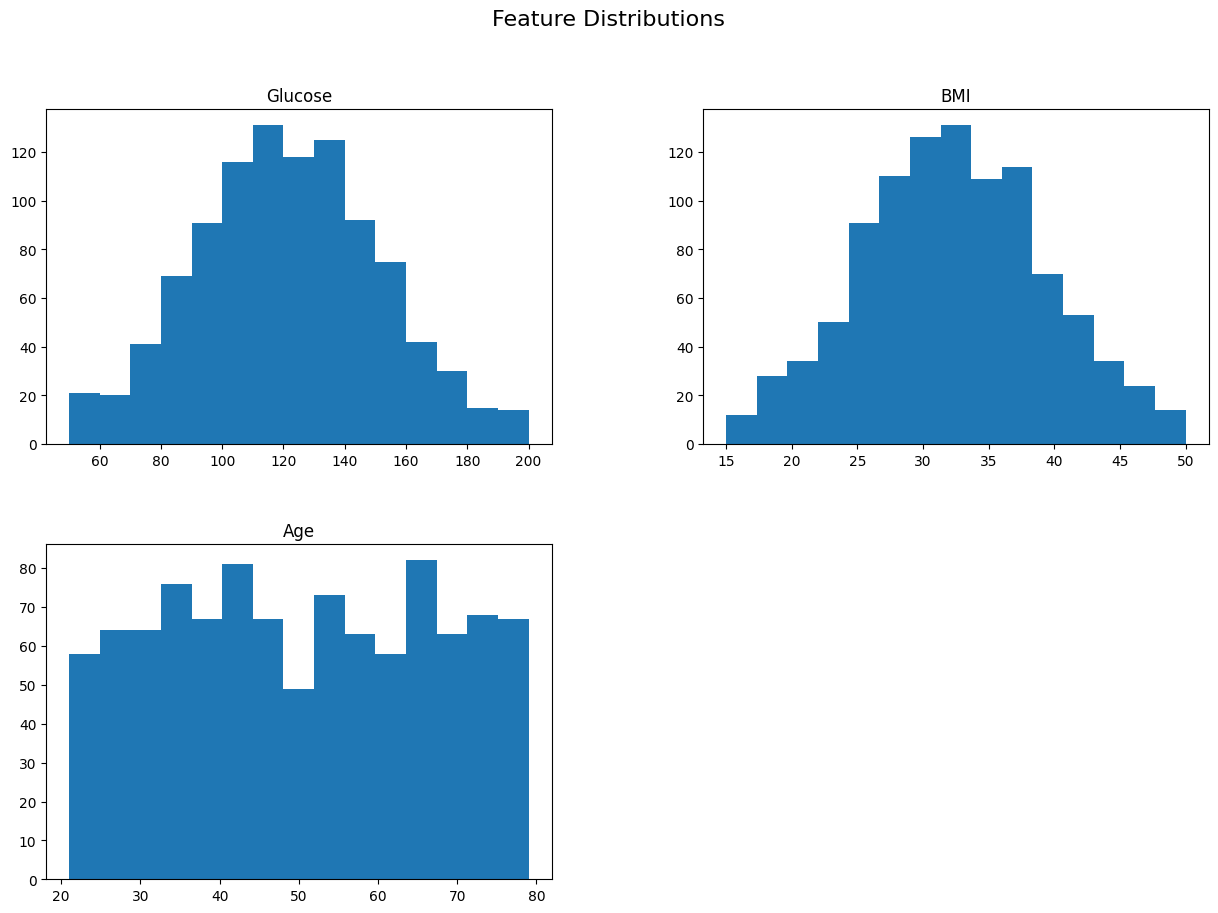

In [4]:
synthetic_data[["Glucose", "BMI", "Age"]].hist(bins=15, figsize=(15, 10), grid=False)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


<ipython-input-5-5b38f9546ec6>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome", y=feature, data=synthetic_data, ax=axes[i], palette="coolwarm")
<ipython-input-5-5b38f9546ec6>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome", y=feature, data=synthetic_data, ax=axes[i], palette="coolwarm")
<ipython-input-5-5b38f9546ec6>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome", y=feature, data=synthetic_data, ax=axes[i], palette="coolwarm")


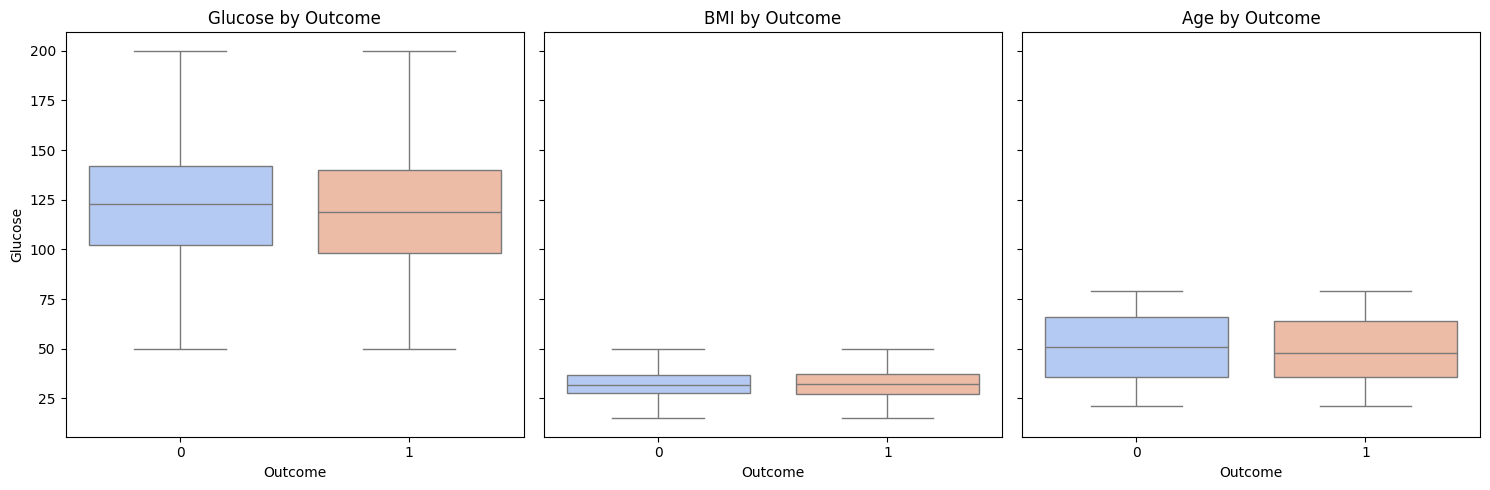

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, feature in enumerate(["Glucose", "BMI", "Age"]):
    sns.boxplot(x="Outcome", y=feature, data=synthetic_data, ax=axes[i], palette="coolwarm")
    axes[i].set_title(f"{feature} by Outcome")

plt.tight_layout()
plt.show()
